# =========================================
# TRAFFIC CONGESTION PREDICTION - REPORT 4
# =========================================


In [12]:
import pandas as pd
import numpy as np
import sqlite3
conn = sqlite3.connect(r"C:\Users\Admin\Desktop\3\ADY201m\data\clean\data_traffic_clean.db")
df = pd.read_sql("SELECT * FROM traffic_data_clean", conn)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Shape: (40064, 8)

Columns: ['id', 'timestamp', 'location', 'current_speed_kmh', 'free_flow_speed_kmh', 'speed_ratio', 'traffic_level', 'confidence']


,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence
0,1,2026-01-12 20:19:56,1,53.0,53.0,1.00,THOANG,1.000000
1,2,2026-01-12 20:19:56,2,39.0,49.0,0.80,DONG,0.990786
2,3,2026-01-12 20:19:56,3,29.0,38.0,0.76,DONG,0.914126
3,4,2026-01-12 20:19:56,4,29.0,39.0,0.74,DONG,0.940000
4,5,2026-01-12 20:19:56,5,30.0,39.0,0.77,DONG,0.928320


In [13]:
from sklearn.preprocessing import LabelEncoder

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Encode
le_target = LabelEncoder()
df['traffic_level'] = le_target.fit_transform(df['traffic_level'])

# Feature Engineering
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 7<=x<=9 or 17<=x<=19 else 0)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Target
y = df['traffic_level']

# Features (time-based only)
X = df[['hour_sin', 'hour_cos', 'is_peak_hour', 'day_of_week']]

df.head()

,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence,hour,day_of_week,is_peak_hour,hour_sin,hour_cos
0,1,2026-01-12 20:19:56,1,53.0,53.0,1.00,2,1.000000,20,0,0,-0.866025,0.5
1,2,2026-01-12 20:19:56,2,39.0,49.0,0.80,0,0.990786,20,0,0,-0.866025,0.5
2,3,2026-01-12 20:19:56,3,29.0,38.0,0.76,0,0.914126,20,0,0,-0.866025,0.5
3,4,2026-01-12 20:19:56,4,29.0,39.0,0.74,0,0.940000,20,0,0,-0.866025,0.5
4,5,2026-01-12 20:19:56,5,30.0,39.0,0.77,0,0.928320,20,0,0,-0.866025,0.5


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (32051, 4)
Test size: (8013, 4)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.4078372644452764
              precision    recall  f1-score   support

           0       0.75      0.23      0.36      4733
           1       0.04      0.51      0.07       207
           2       0.54      0.67      0.60      3073

    accuracy                           0.41      8013
   macro avg       0.44      0.47      0.34      8013
weighted avg       0.65      0.41      0.44      8013


=== Random Forest ===
Accuracy: 0.46798951703481845
              precision    recall  f1-score   support

           0       0.76      0.32      0.45      4733
           1       0.05      0.57      0.10       207
           2       0.56      0.68      0.61      3073

    accuracy                           0.47      8013
   macro avg       0.46      0.53      0.39      8013
weighted avg       0.66      0.47      0.51      8013



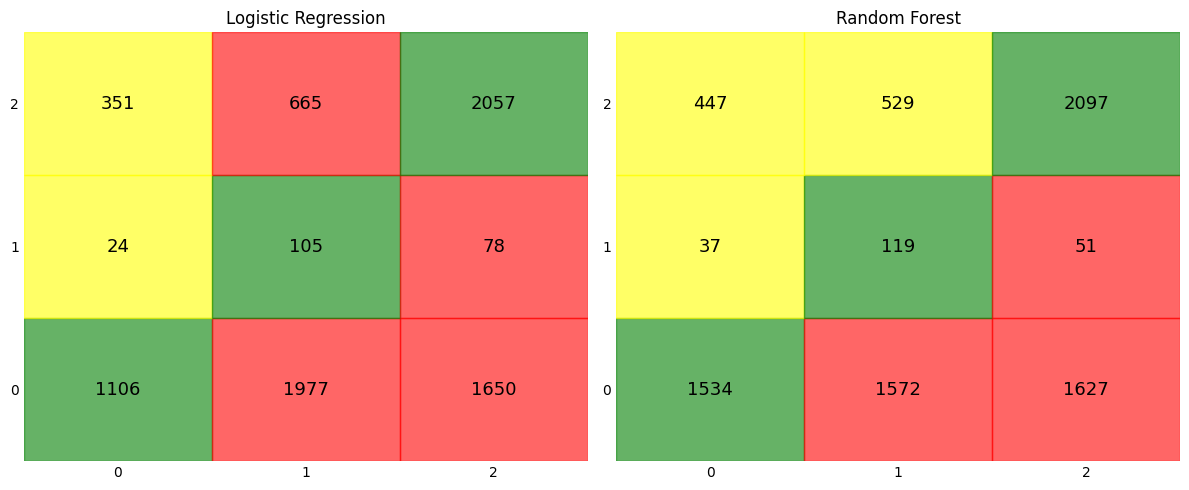

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_custom(cm, title, ax):
    cm = cm.astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ratio = cm_norm[i, j]

            if i == j:
                color = 'green'
            elif ratio < 0.2:
                color = 'yellow'
            else:
                color = 'red'

            rect = plt.Rectangle((j, i), 1, 1, color=color, alpha=0.6)
            ax.add_patch(rect)

            value = int(cm[i, j])
            ax.text(j + 0.5, i + 0.5, str(value),
                    ha='center', va='center', fontsize=13)

    ax.set_xlim(0, cm.shape[1])
    ax.set_ylim(0, cm.shape[0])

    ax.set_xticks(np.arange(cm.shape[1]) + 0.5)
    ax.set_yticks(np.arange(cm.shape[0]) + 0.5)

    ax.set_xticklabels(range(cm.shape[1]))
    ax.set_yticklabels(range(cm.shape[0]))

    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)
    


# ===== ÁP DỤNG =====
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_confusion_matrix_custom(cm_log, "Logistic Regression", axes[0])
plot_confusion_matrix_custom(cm_rf, "Random Forest", axes[1])
plt.tight_layout()
plt.show()

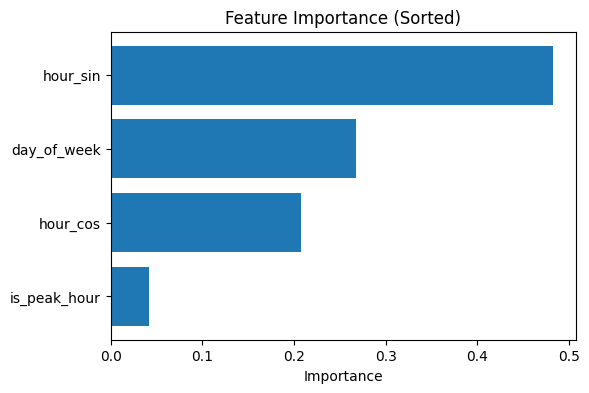

In [ ]:
importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(6,4))
plt.barh(np.array(features)[indices], importances[indices])
plt.title("Feature Importance (Sorted)")
plt.xlabel("Importance")
plt.show()

## Model Evaluation

- Random Forest đạt độ chính xác cao hơn Logistic Regression.
- Tuy nhiên, cả hai model đều có accuracy trung bình (~0.4 - 0.47) do chỉ sử dụng temporal features.

## Key Findings

- Feature quan trọng nhất: hour_sin → thời gian trong ngày ảnh hưởng lớn nhất.
- day_of_week cũng có ảnh hưởng đáng kể.
- is_peak_hour có tác động thấp hơn kỳ vọng.

## Confusion Matrix Insights

- Model có khả năng nhận diện class hiếm (traffic_level = 1).
- Tuy nhiên, vẫn có sự nhầm lẫn giữa các mức độ giao thông.

## Conclusion

- Thời gian có ảnh hưởng đến giao thông nhưng không đủ để dự đoán chính xác.
- Cần bổ sung thêm feature như location hoặc speed để cải thiện model.